# OT on Tahoe-100M dataset via centroid-level integration
In this notebook, we’ll generate an OT embedding on the Tahoe-100M dataset, which contains cells from various cell lines under different treatments, and then visualize a subset of the data.

Exact optimal transport scales roughly quadratically with the number of cells, so running OT directly on ~100M cells is infeasible.  
To make this tractable, we:

1. Compress each batch into ~2k centroids (MiniBatchKMeans on up to 500k cells per batch).
2. Run scBIOT’s OT integration only on these centroids.
3. Learn a displacement field on the centroids and interpolate it back to all 100M cells using FAISS k-NN.

The `integrate_centroids` call below implements this centroid-level OT + displacement mapping.


### Out-of-core Analysis

For generating PCA embedding: see [here] (https://theislab.github.io/vevo_Tahoe_100m_analysis/vevo_100m_pca.html)

For rapids-singlecell tutorials, see [here](https://rapids-singlecell.readthedocs.io/en/latest/notebooks/multi_gpu_show.html) for scanpy, see [here](https://scanpy.readthedocs.io/en/stable/tutorials/experimental/dask.html)

## Setup
Import dependencies and set GPU/CPU execution flags.

In [ ]:
from pathlib import Path

import scbiot as scb

import numpy as np
import dask.distributed as dd
import scanpy as sc
import anndata as ad
import h5py
import dask

from collections import Counter
import pandas as pd
from tqdm import tqdm
import dask
import time
from dask.distributed import Client, LocalCluster

import dask

sc.logging.print_header()

## Technical Notes

To turn on one or the other of GPU or CPU, use the flag below. If you are using a GPU, configure the `gpus` flag accordingly to the number of GPUs you have available.  Similarly, for the CPU implementation, you can configure the number of workers.  We ran this notebook using CPU with a slurm configuration like `srun ... -c 32 --mem=300gb`, using 16 dask workers and the below sparse chunks size while we were only able to get one GPU, although the beauty of `dask` is that one is enough to complete the analysis thanks to the out-of-core capabilities.  You can of course use fewer CPU cores and this notebook will still be runnable, such is the beauty of truly lazy, chunked computation.  Nothing is loaded into memory until it is needed, and only the amount needed to perform the local computation on a chunk of the data.

The interplay between memory and workers is delicate - too many workers and not enough memory will cause your calculation to crash, so often it is good to have a few fewer workers than you think would be best.  For example, because a single GPU has somewhere in the range of 32GB, that is more than the individual 16 workers can have who split the 300GB, thereby allowing for a larger chunk size.  Furthermore with [rapids-memory-management](https://github.com/rapidsai/rmm), memory concerns are not so overriding on the GPU.

**Caution**: Out-of-core support is still quite new in both packages, so we are learning more and more daily about performance optimizations. The information here about performance thus represents our best attempt to provide advice on performance. On only one GPU, preprocessing can be quite lengthy, and therefore it is advisable to use rapids only with more than one GPU (be sure to update the `gpus` variable accordingly to reflect this - it should be something like `'0,1,2,3'`, for example, for four GPUs).  Otherwise, we have observed that the single-GPU PCA is faster than the multi-core PCA (~12.5 min vs. ~18 min), but the time needed to bring the data back to the CPU from the GPU for writing causes the two to be comparable i.e., PCA + writing the results has the same time between one GPU and multi-core CPU with the above specs.

In [2]:
use_gpu = False

In [3]:
# Local-only setup: no HPC / no external Dask cluster
if use_gpu:
    import rapids_singlecell as rsc
    SPARSE_CHUNK_SIZE = 1_000_000

    import rmm
    import cupy as cp
    from cupyx.scipy import spx
    from rmm.allocators.cupy import rmm_cupy_allocator

    # Initialize GPU memory on *local* GPU
    def set_mem():
        rmm.reinitialize(managed_memory=True)
        cp.cuda.set_allocator(rmm_cupy_allocator)

    import dask.array as da
    dask.array.register_chunk_type(spx.csr_matrix)

    set_mem()
    mod = rsc
else:
    # Pure CPU mode on local machine
    SPARSE_CHUNK_SIZE = 100_000
    mod = sc


## Preprocessing

First, let's do some standard preprocessing on the datasets.  Note that we use `ad.experimental.read_elem_as_dask` to load the big data, the cell x gene matrix, lazily.  The preprocessing is then done lazily i.e., normalization, log1p, and highly variable gene selection.  Individually, we'll do this and then merge all the datasets into one large dataset to be used in the next step. We'll finally merge the data into one large `AnnData` for the PCA.  Writing this out and then reading it back in is faster than rechunking a virtually concatenated i.e., `anndata.concat` dataset (`dask` requires uniform chunks, which would not be possible without rechunking).

In [4]:
# %%time
# adatas = []
# all_highly_variable_genes = []
# for i in tqdm(range(14)):
#     id = str(i + 1)
#     PATH = f"/c4/scratch/haihui/tahoe100m_h5ad/plate{id}_filt_Vevo_Tahoe100M_WServicesFrom_ParseGigalab.h5ad"

#     with h5py.File(PATH, "r") as f:
#         # obs / var as before
#         adata = ad.AnnData(
#             obs=ad.io.read_elem(f["obs"]),
#             var=ad.io.read_elem(f["var"]),
#         )
#         # NEW: use read_elem_lazy instead of read_elem_as_dask
#         adata.X = ad.experimental.read_elem_lazy(
#             f["X"], chunks=(SPARSE_CHUNK_SIZE, adata.shape[1])
#         )

#     if use_gpu:
#         rsc.get.anndata_to_GPU(adata)

#     # 100m filtering
#     pass_filter_mask = adata.obs["pass_filter"] == "full"
#     adata = adata[pass_filter_mask, :].copy()

#     sc.pp.normalize_total(adata)
#     sc.pp.log1p(adata)
#     sc.pp.highly_variable_genes(adata, n_top_genes=2000)

#     highly_variable_genes = set(adata.var_names[adata.var["highly_variable"]])
#     all_highly_variable_genes.append(highly_variable_genes)
#     adatas.append(adata)

# ## select the genes appears more than two plates
# gene_counts = Counter(gene for genes in all_highly_variable_genes for gene in genes)
# selected_genes = {gene for gene, count in gene_counts.items() if count > 2}

# for i in tqdm(range(14)):
#     id = str(i + 1)

#     # use the var_names of the i-th plate
#     common_genes = list(set(adatas[i].var_names) & selected_genes)
#     adata_i = adatas[i][:, common_genes].copy()

#     output_path = f"/c4/scratch/haihui/processed/plate{id}_filtered_preprocessed_{'gpu' if use_gpu else 'cpu'}.h5ad"
#     adata_i.write_h5ad(output_path)


## Merge all data into giant file

We'll now merge the data into one large file for the PCA.  This is faster than rechunking a virtually concatenated i.e., `anndata.concat` dataset (`dask` requires uniform chunks, which would not be possible without rechunking).  Furthermore, rechunking can cause a memory blow-up.

In [5]:
# %%time
# data_dict = {}
# for i in range(14):
#     data_dict.update({f"plate_{i+1}": f"/c4/scratch/haihui/processed/plate{id}_filtered_preprocessed_{'gpu' if use_gpu else 'cpu'}.h5ad"})
# ad.experimental.concat_on_disk(
#     data_dict,
#     f'/c4/scratch/haihui/processed/plate_merged_{"gpu" if use_gpu else "cpu"}.h5ad',
#     label='plate',
# )

## Calculate cell embeddings

To do this we will use PCA.  Both `scanpy` and `rapids_singlecell` provide out-of-core implementations of PCA on sparse datasets.

In [4]:
%%time
with h5py.File(f"/home/figo/software/python_libs/plate_merged_{'gpu' if use_gpu else 'cpu'}.h5ad", "r") as f:
    adata = ad.AnnData(
        obs=ad.io.read_elem(f["obs"]),
        var=ad.io.read_elem(f["var"]),
    )
    adata.X = ad.experimental.read_elem_lazy(
    f["X"], chunks=(SPARSE_CHUNK_SIZE, adata.shape[1])
)


CPU times: user 43.9 s, sys: 27.6 s, total: 1min 11s
Wall time: 1min 15s


In [7]:
adata

AnnData object with n_obs × n_vars = 86815078 × 2304
    obs: 'sample', 'gene_count', 'tscp_count', 'mread_count', 'drugname_drugconc', 'drug', 'cell_line', 'sublibrary', 'BARCODE', 'pcnt_mito', 'S_score', 'G2M_score', 'phase', 'pass_filter', 'cell_name', 'plate'

In [8]:
%%time
if use_gpu:
    rsc.get.anndata_to_GPU(adata)

CPU times: user 2 μs, sys: 0 ns, total: 2 μs
Wall time: 5.72 μs


In [9]:
# %%time
# mod.pp.pca(adata, n_comps=300, mask_var=None)
# if use_gpu:
#     adata.obsm["X_pca"] = adata.obsm["X_pca"].map_blocks(
#         lambda x: x.get(), meta=np.array([]), dtype=adata.obsm["X_pca"].dtype
#     ) # bring back to CPU

In [10]:
# %%time
# adata.obsm["X_pca"].to_zarr(f"/c4/scratch/haihui/processed/plate_merged_pca_{'gpu' if use_gpu else 'cpu'}.zarr")

## Export
Persist PCA/OT embeddings to disk and reload them as needed.
Now the data can be read back in with `dask` if needed and put into the `anndata` object.  A slight more complex way to write the data, but perhaps more `anndata`-ic would have been to use `write_elem`: https://anndata.readthedocs.io/en/latest/generated/anndata.io.write_elem.html

In [11]:
%%time
adata.obsm["X_pca"] = dask.array.from_zarr(f"/home/figo/software/python_libs/plate_merged_pca_{'gpu' if use_gpu else 'cpu'}.zarr")

CPU times: user 3.66 ms, sys: 936 μs, total: 4.6 ms
Wall time: 4.19 ms


## Integrate
Run centroid-level OT on the PCA embedding and store the OT coordinates.

In [ ]:

adata, metrics = scb.ot.integrate_centroids(
    adata, 
    obsm_key='X_pca', 
    batch_key='plate', 
    out_key='X_ot',    
    n_centroids_per_batch=2048,   # tune: fewer = faster, more = better fidelity
    max_samples_per_batch=500_000,
    chunk_size=1_000_000,                     
    use_gpu = True,                              
    verbose = True                     
                )
print(metrics)

## Visualization

Briefly, we visualize a subset of the results to avoid meaningless overplotting.  However, the full PCA results are still available on disk and are ready for use downstream, whether in deep-learning applications or for simple linear classifiers.

In [ ]:
# %%time
# adata.obsm["X_ot"] = dask.array.from_zarr(f"/home/figo/software/python_libs/plate_merged_ot_{'gpu' if use_gpu else 'cpu'}.zarr")

CPU times: user 1.82 ms, sys: 8.41 ms, total: 10.2 ms
Wall time: 23.7 ms


In [6]:
%%time
adata = adata[np.random.randint(0, adata.shape[0], (1_000_000,))]
adata

CPU times: user 767 ms, sys: 4.58 ms, total: 772 ms
Wall time: 803 ms


View of AnnData object with n_obs × n_vars = 1000000 × 2304
    obs: 'sample', 'gene_count', 'tscp_count', 'mread_count', 'drugname_drugconc', 'drug', 'cell_line', 'sublibrary', 'BARCODE', 'pcnt_mito', 'S_score', 'G2M_score', 'phase', 'pass_filter', 'cell_name', 'plate'
    obsm: 'X_ot'

In [7]:
%%time
mod.pp.neighbors(adata, use_rep='X_ot')

CPU times: user 7min 17s, sys: 5min 36s, total: 12min 53s
Wall time: 7min 30s


In [8]:
%%time
mod.tl.umap(adata)
if use_gpu:
    adata.obsm["X_umap"] = adata.obsm["X_umap"].get()

CPU times: user 2h 57min 54s, sys: 20.4 s, total: 2h 58min 14s
Wall time: 8min 22s


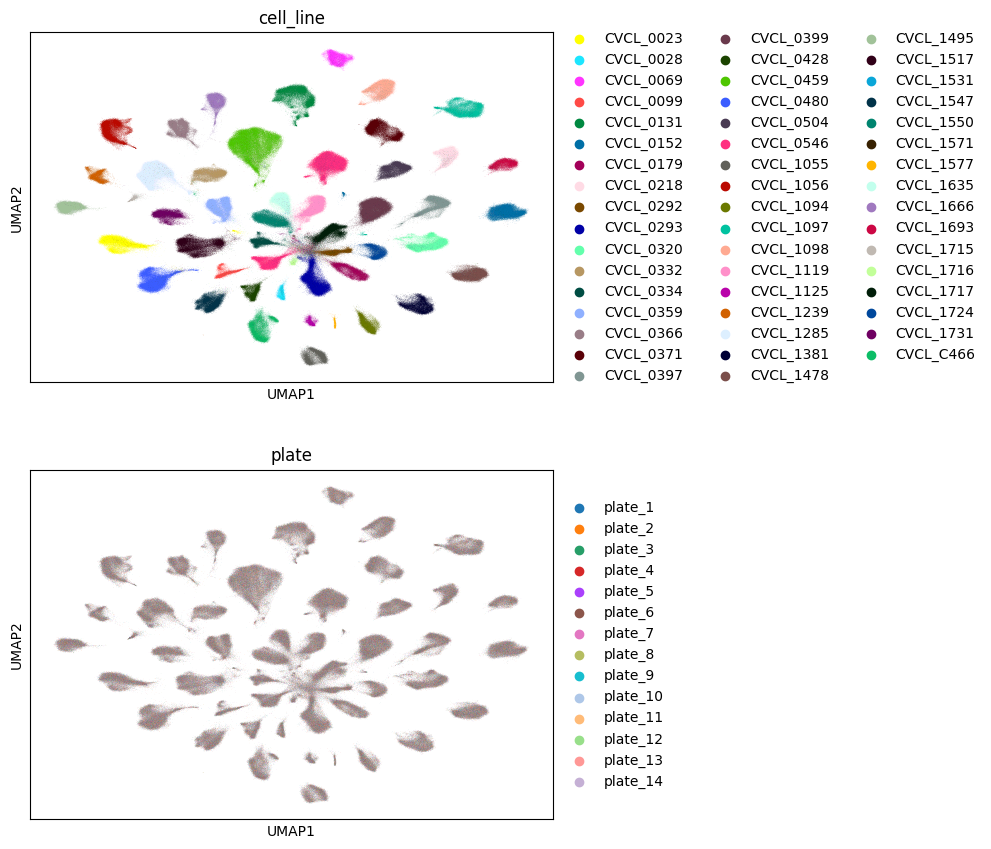

CPU times: user 4.97 s, sys: 7.32 ms, total: 4.97 s
Wall time: 4.97 s


In [9]:
%%time
sc.pl.umap(
    adata,
    color=["cell_line", "plate"],
    ncols=1
)

In [ ]:
%%time
mod.tl.leiden(
    adata, 
    resolution=0.8,   
    key_added="leiden")